# Titanic分析

`exploratory-data-analysis`の手順に沿ってデータを確認し、リーケージを避けた前処理Pipelineで生存予測モデルを比較します。

In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. データ形状・型・欠損

In [3]:
print('train shape:', train.shape)
print('test shape :', test.shape)
display(train.dtypes.to_frame('dtype'))
missing = train.isna().sum().to_frame('missing_count')
missing['missing_rate'] = (missing['missing_count'] / len(train)).round(3)
display(missing.sort_values('missing_count', ascending=False))


train shape: (891, 12)
test shape : (418, 11)


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


,missing_count,missing_rate
Cabin,687,0.771
Age,177,0.199
Embarked,2,0.002
PassengerId,0,0.000
Survived,0,0.000
Pclass,0,0.000
Name,0,0.000
Sex,0,0.000
SibSp,0,0.000
Parch,0,0.000


## 2. 目的変数と単変量・二変量分析

,count,rate
Survived,,
0,549,0.616162
1,342,0.383838


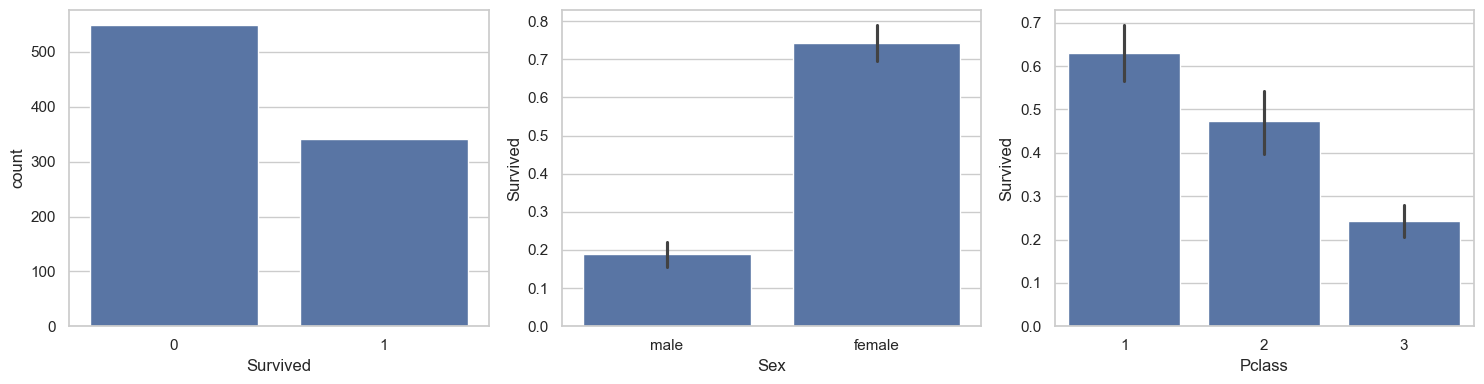

count   mean
Sex    Pclass              
female 1          94  0.968
       2          76  0.921
       3         144  0.500
male   1         122  0.369
       2         108  0.157
       3         347  0.135

,count,mean
Embarked,,
C,168,0.554
Q,77,0.390
S,644,0.337


In [4]:
display(train['Survived'].value_counts().rename('count').to_frame().assign(rate=lambda d: d['count']/len(train)))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=train, x='Survived', ax=axes[0])
sns.barplot(data=train, x='Sex', y='Survived', ax=axes[1])
sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[2])
plt.tight_layout()
plt.show()

display(train.groupby(['Sex', 'Pclass'], observed=True)['Survived'].agg(['count','mean']).round(3))
display(train.groupby('Embarked', observed=True)['Survived'].agg(['count','mean']).round(3))


## 3. 特徴量準備とリーケージ対策

`PassengerId`、`Name`、`Ticket`、`Cabin`はそのまま使わず、まず解釈しやすい`Title`、`FamilySize`、`IsAlone`、`Deck`を作ります。欠損補完・エンコード・標準化はPipeline内で学習データだけから適合させます。

In [5]:
def make_features(df):
    out = df.copy()
    out['Title'] = out['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()
    rare = ~out['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master'])
    out.loc[rare, 'Title'] = 'Rare'
    out['FamilySize'] = out['SibSp'] + out['Parch'] + 1
    out['IsAlone'] = (out['FamilySize'] == 1).astype(int)
    out['Deck'] = out['Cabin'].str[0].fillna('U')
    return out.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

X = make_features(train)
y = train['Survived']
print(X.columns.tolist())
display(X.head())


['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Deck']


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,Deck
0,3,male,22.0,1,0,7.2500,S,Mr,2,0,U
1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,C
2,3,female,26.0,0,0,7.9250,S,Miss,1,1,U
3,1,female,35.0,1,0,53.1000,S,Mrs,2,0,C
4,3,male,35.0,0,0,8.0500,S,Mr,1,1,U


## 4. Pipelineによるモデル評価

In [6]:
numeric = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck']
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical),
])
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=400, min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, estimator in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', estimator)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=['accuracy', 'roc_auc', 'f1'], n_jobs=-1)
    results.append({'model': name, 'accuracy_mean': scores['test_accuracy'].mean(), 'accuracy_std': scores['test_accuracy'].std(), 'roc_auc_mean': scores['test_roc_auc'].mean(), 'f1_mean': scores['test_f1'].mean()})
results = pd.DataFrame(results).sort_values('roc_auc_mean', ascending=False)
display(results.round(3))


,model,accuracy_mean,accuracy_std,roc_auc_mean,f1_mean
1,RandomForest,0.837,0.015,0.880,0.773
0,LogisticRegression,0.829,0.018,0.872,0.773


## 5. まとめ

- `Survived`は不均衡だが極端ではないため、AccuracyだけでなくROC-AUCとF1も併記します。
- `Age`、`Cabin`、`Embarked`、`Fare`に欠損があり、補完はPipeline内で実施します。
- 性別・客室等級は生存率との関係が強く、`Title`・家族特徴・Deckを候補特徴量にします。
- 交差検証の結果を基準にモデルを選び、Kaggle提出時はtrain全体で再学習します。